# 4n-MRC Analysis

In [1]:
# import
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import MDAnalysis as mda
import xarray as arr
import mdtraj as md
import scipy
from MDAnalysis.analysis import distances

In [2]:
# paths to simulations
path1 = "/data/geissler/simulations/rec_lig/4n-mrc/1rep/"  # path to replica1
path2 = "/data/geissler/simulations/rec_lig/4n-mrc/2rep/"  # path to replica2
path3 = "/data/geissler/simulations/rec_lig/4n-mrc/3rep/"  # path to replica3
path_combined = "/data/geissler/simulations/rec_lig/4n-mrc/combined/"  # path to folder with concatenated version of all 3 replicas
path_stats = "/data/geissler/simulations/rec_lig/4n-mrc/combined/stats/"  # path to save results

## RMSD Calcium and Ligand to pocket

### Cal to pocket

RMSD was calculated with gromacs using the protein backbone as the group for least squares fit and the Calcium atom for the RMSD calculation. The trajectory was centered on the pocket atoms, otherwise the calcium atoms jumps in and out of the box.

In [22]:
# load data
rmsd_cal_center = np.loadtxt(f"{path_stats}cal_center_rmsd.xvg",
                     comments =['#','@'])
rmsd_cal_center[:, 0] = np.arange(0, 15003)  # 500 ns each replica
rmsd_lig = np.loadtxt(f"{path_stats}rmsd_lig.xvg",
                     comments =['#','@'])
rmsd_lig[:, 0] = np.arange(0, 15003)  # 500 ns each replica

In [23]:
# smooth RMSD over 20 frames
def movingaverage(values, window):
    weights = np.repeat(1.0, window)/window
    sma = np.convolve(values, weights, 'valid')
    return sma
av = 20

In [24]:
rmean_cal = movingaverage(rmsd_cal_center[:,1], av)
rmean_lig = movingaverage(rmsd_lig[:,1], av)

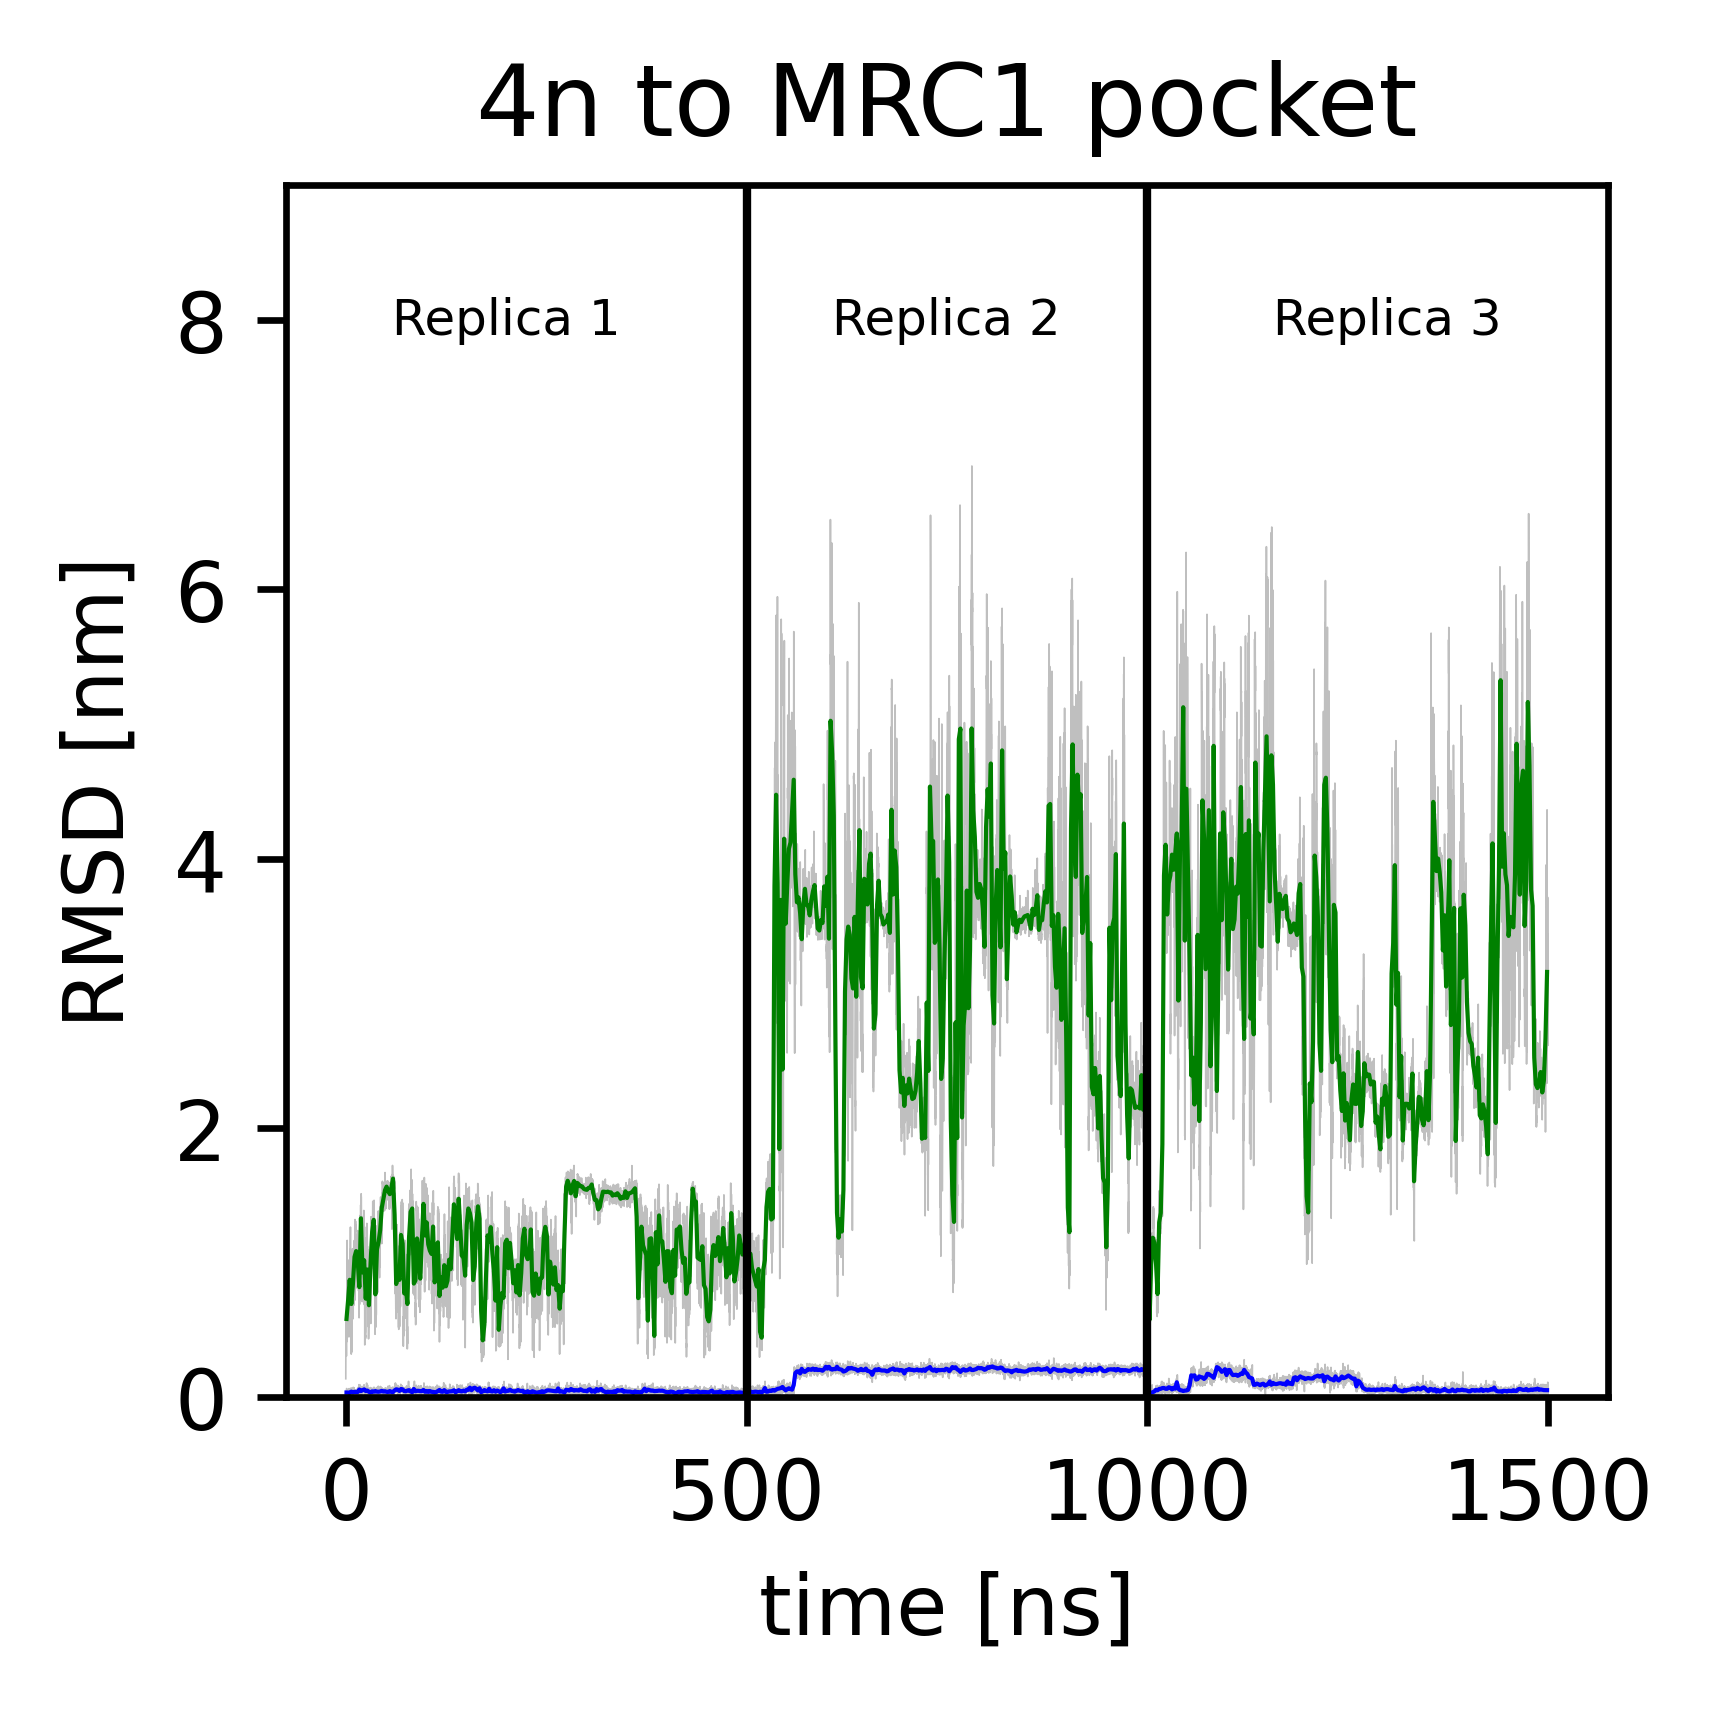

In [26]:
# plot RMSD
cm = 1/2.54
fig, ax = plt.subplots(figsize=(7.5*cm, 7.5*cm), dpi=600)

ax.plot(rmsd_cal_center.T[1], linewidth=0.2, c='grey', alpha=0.5)  # RMSD Cal
ax.plot(rmsd_cal_center[int(av/2-1):-int(av/2),0][::av]/1, rmean_cal[::av], linewidth=0.5, c='#0000FF') # smoothed RMSD Cal
ax.plot(rmsd_lig.T[1], linewidth=0.2, c='grey', alpha=0.5)  # RMSD lig
ax.plot(rmsd_lig[int(av/2-1):-int(av/2),0][::av]/1, rmean_lig[::av], linewidth=0.5, c='green') # smoothed RMSD lig
plt.axvline(5000, color='#000000', linewidth=1)  # borders between replica
plt.axvline(10000, color='#000000', linewidth=1)

plt.text(2000, 8, "Replica 1", size=6, rotation=0.,  # labels
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))
plt.text(7500, 8, "Replica 2", size=6, rotation=0.,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))
plt.text(13000, 8, "Replica 3", size=6, rotation=0.,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))

ax.set_ylim(0,9)
# ax.set_xlim(0,15010)
plt.xticks([0, 5000, 10000, 15000,], ['0', '500', '1000', '1500',], fontsize=10)
plt.title('4n to MRC1 pocket')
ax.set_xlabel('time [ns]')
ax.set_ylabel('RMSD [nm]')
plt.tight_layout()
plt.savefig("/data/geissler/analysis/RMSD/cal_lig/4n-mrc.png")

## different binding states

Here I define the different binding conformations ("binding states") by distances of different mannose Hydroxy-groups to different amino acids in the binding pocket of the receptor: 
<br> 
(the different HO-groups are hightlighted in Fig.5 of the paper)
- the "crystal state" is defined by HO4 being close to Glu725, HO3 being close to Glu733, HO6 being far away from Glu737 and HO2 being far away from Glu725
- "state A" is defined by HO2 being close to Glu725, HO4 being far from Glu725, HO6 being far from Glu737 and HO2 being far from Glu733
- "state B" is defined by HO2 being close to Glu733, HO4 being far from Glu725, HO6 being far from Glu737 and HO2 being far from Glu725
- "state C" is defined by HO6 being close to Glu737, HO3 being close to Glu733 and HO2 being far from Glu725 

In [3]:
# for the calculations I concatenated all frames of ligand being bound to the pocket
traj = mda.Universe(path_combined+'md_500ns.pdb',
                   path_combined+'combined_bound.xtc')

As I define the binding states by distances, I calculate the different distances between HO atoms and the respective amino acids

In [4]:
# this calculates the distance between the two defined atoms below for each frame of the simulation and appends them to a list
# distance 1: HO6 to Glutamic Acid 737
man = traj.select_atoms('resname LIG and name HO6')
prot = traj.select_atoms('protein and resid 737 and name CD') 

distance1 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance1.append(dist_arr/10)  # convert from Angstr. to nm

In [5]:
# distance 2: HO2 to Glutamic Acid 725
man = traj.select_atoms('resname LIG and name HO2')
prot = traj.select_atoms('protein and resid 725 and name CD')

distance2 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance2.append(dist_arr/10)  # convert from Angstr. to nm

In [6]:
# distance 3: HO3 to Glutamic Acid 733
man = traj.select_atoms('resname LIG and name HO3')
prot = traj.select_atoms('protein and resid 733 and name CD')

distance3 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance3.append(dist_arr/10)  # convert from Angstr. to nm

In [7]:
# distance 4: HO4 to Glutamic Acid 725 
man = traj.select_atoms('resname LIG and name HO4')
prot = traj.select_atoms('protein and resid 725 and name CD')

distance4 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance4.append(dist_arr/10)  # convert from Angstr. to nm

In [8]:
# distance 5: HO2 to Glutamic Acid 733
man = traj.select_atoms('resname LIG and name HO2')  
prot = traj.select_atoms('protein and resid 733 and name CD')

distance5 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance5.append(dist_arr/10)  # convert from Angstr. to nm

In [9]:
# now I put them into 1 array
all_distances=np.column_stack((distance1,distance2,distance3,distance4,distance5))
# and make it flat
distances_flat=all_distances[:,:,0]
np.save('distances_flat.npy', distances_flat)

Now I sort the frames into their respective state. I defined the cutoff between close and far at 3.5 Ångström which roughliy corresponds to the length of a hydrogen bond.

In [10]:
# crystal state: HO4 close to Glu725, HO3 close to Glu733, HO6 far away from Glu737 and HO2 far away from Glu725
crystal = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][3] <= 0.35 and distances_flat[i][2] <= 0.35 and distances_flat[i][0] > 0.35 and distances_flat[i][1] > 0.35:
        crystal.append(i)
print(len(crystal))  # print how many frames correspond to the crystal state

453


In [11]:
# state A: HO2 close to Glu725, HO4 far from Glu725, HO6 far from Glu737 and HO2 far from Glu733
stateA = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][1] <= 0.35 and distances_flat[i][3] > 0.35 and  distances_flat[i][0] > 0.35 and distances_flat[i][4] > 0.35:
        stateA.append(i)
print(len(stateA))

0


In [12]:
# state B: HO2 close to Glu733, HO4 far from Glu725, HO6 far from Glu737 and HO2 far from Glu725
stateB = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][4] <= 0.35 and distances_flat[i][3] > 0.35 and distances_flat[i][0] > 0.35 and distances_flat[i][1] > 0.35:
        stateB.append(i)
print(len(stateB))

124


In [13]:
# state C: HO6 close to Glu737, HO3 close to Glu733 and HO2 far from Glu725
stateC = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][0] <= 0.35 and distances_flat[i][2] <= 0.35 and distances_flat[i][1] > 0.35:
        stateC.append(i)
print(len(stateC))

4157


In [14]:
# this is how I find out how many frames do not fall into any defined state ("others")
len(distances_flat)-len(crystal)-len(stateA)-len(stateB)-len(stateC)

629

## get frames of specific states to make a trajectory

For mmPBSA calculation for the specific states and for producing state contact maps, I will bin the frames of the same state together into one state specific trajectory. 
<br>
I will make trajectories between 100 and 300 frames, to have better comparability.
<br>
By multiplying the frame numbers with 100 ps and considering the order of replicas, I can use the output below directly as input for the 'states_trajectory.sh' bash script.

This is what the combined bound traj is made of:

- 1rep bound: 5001 frames, 500 ns, 500100 ps
- 2rep bound: 231 frames, 23 ns, 23100 ps
- 3rep bound: 131 frames, 13 ns, 13100 ps

  5363 frames in total -> 536300 ps

### crystal state

In [15]:
ps = 100
crystal_ps= [x*ps for x in crystal] 
print(*crystal_ps[:300])

0 100 200 300 400 500 600 700 800 900 1800 1900 2000 2100 2200 2300 2400 2800 2900 3000 3100 3200 3300 3400 3500 3600 3700 3800 3900 4000 4100 4200 4300 4400 4500 4600 4700 4800 4900 5000 5100 5200 5400 5500 5600 5700 5800 5900 6000 6100 6200 6300 6400 6500 6600 6700 6800 6900 7000 7100 7200 7300 7400 7500 7600 7700 7900 8000 8100 8200 8300 8400 8500 8600 8700 8800 8900 9000 9100 9200 9300 9400 9500 9600 9700 9800 9900 10100 10200 10300 10400 10500 10600 10700 10800 10900 11000 11100 11200 11300 11400 11500 11600 11700 11800 11900 12000 12100 12200 12300 12400 12600 12700 12800 13000 13100 13200 13300 13400 13500 13600 13700 13800 13900 14100 14200 14400 14500 14600 14700 14900 15100 15200 15300 15400 15500 15600 15700 65400 122800 203500 314900 323800 328200 330600 334700 336200 339300 348500 477500 500100 500200 500300 500400 500500 500600 500700 500800 500900 501000 501100 501200 501300 501400 501500 501600 501700 501800 501900 502000 502100 502200 502300 502400 502500 502600 502700

In [16]:
print('frames in 1rep:')
for i in crystal_ps[:300]:
    if i <= 500100:
        print(i)

frames in 1rep:
0
100
200
300
400
500
600
700
800
900
1800
1900
2000
2100
2200
2300
2400
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12600
12700
12800
13000
13100
13200
13300
13400
13500
13600
13700
13800
13900
14100
14200
14400
14500
14600
14700
14900
15100
15200
15300
15400
15500
15600
15700
65400
122800
203500
314900
323800
328200
330600
334700
336200
339300
348500
477500
500100


In [18]:
print('frames in 2rep:')
for i in crystal_ps[:500]:
    if i > 500100 and i <= (500100+23100):
        print(i-500100)

frames in 2rep:
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12500
12600
12700
12800
12900
13000
13100
13200
13300
13400
13500
13600
13700
13800
13900
14000
14100
14200
14300
14400
14500
14600
14700
14800
14900
15000
15100
15200
15300
15400
15500
15700
15800
15900
16000
16100
16200
16300
16400
16500
16600
16700
16800
16900
17000
17100
17200
17300
17400
17500
17600
17800
17900
18000
18100
18200
18300
18400
18500
18600
18700
18800
18900
19000
19100
19200
19300
19400
19500
19600
19700
19800
19900
20000
20100
20200
20

### state A has less than 100 frames

### state B

In [19]:
ps = 100
stateB_ps= [x*ps for x in stateB] 
print(*stateB_ps[:300])

1400 1500 1600 1700 2500 2600 2700 5300 7800 10000 12500 14000 14300 14800 15000 15800 15900 16000 16100 16200 16300 16400 16500 16600 16700 16800 16900 17000 17100 17200 17300 17400 17500 17600 17700 17800 17900 18000 18100 18200 76200 104600 122200 123800 163000 203600 203700 203800 208400 287800 287900 301000 304500 311200 311500 311600 311700 313600 313900 314100 314200 314300 314400 314700 315100 315200 315400 315700 316200 316400 316700 316800 317000 317300 317400 317500 323000 324300 328500 330100 331600 332900 335000 338400 341200 342200 345900 346000 346800 346900 349000 397400 477400 488700 507900 508000 508500 509400 509800 515700 517800 520900 521000 521100 521200 521400 521700 521800 521900 522100 523800 529000 529100 530600 530700 530800 530900 531000 531100 531200 531300 531400 531500 536000


In [20]:
print('frames in 2rep:')
for i in stateB_ps[:500]:
    if i > 500100 and i <= (500100+23100):
        print(i-500100)

frames in 2rep:
7800
7900
8400
9300
9700
15600
17700
20800
20900
21000
21100
21300
21600
21700
21800
22000


### state C

In [21]:
ps = 100
stateC_ps= [x*ps for x in stateC] 
print(*stateC_ps[:300])

18400 18500 18600 18700 18800 18900 19000 19100 19200 19300 19400 19500 19600 19700 19800 19900 20000 20100 20200 20300 20400 20500 20600 20700 20800 20900 21000 21100 21200 21300 21400 21500 21600 21700 21800 21900 22000 22100 22200 22300 22400 22500 22600 22700 22800 22900 23000 23100 23200 23300 23400 23500 23600 23700 23800 23900 24000 24100 24200 24300 24400 24500 24600 24700 24800 24900 25000 25100 25200 25300 25400 25500 25600 25700 25800 25900 26000 26100 26200 26300 26400 26500 26600 26700 26800 26900 27000 27100 27200 27300 27400 27500 27600 27700 27800 27900 28000 28100 28200 28300 28400 28500 28600 28700 28800 28900 29000 29100 29200 29300 29400 29500 29600 29700 29800 29900 30000 30100 30200 30300 30400 30500 30600 30700 30800 30900 31000 31100 31200 31300 31400 31500 31600 31700 31800 31900 32000 32100 32200 32300 32400 32500 32600 32700 32800 32900 33900 34000 34100 34200 34300 34400 34500 34600 34700 34800 34900 35000 35100 35200 35300 35400 35500 35600 35700 35800 3590

all frames are in replica 1.